# Project Title
## Loan Approval Prediction Using Machine Learning

# Overview

Financial institutions receive a large number of loan applications every day. Evaluating each application manually is time-consuming and may lead to inconsistent decisions. This project aims to automate the loan approval process using Machine Learning by predicting whether a loan application should be approved or rejected based on applicant information.

The model analyzes factors such as applicant income, loan amount, credit history, education level, marital status, employment status, and property area to determine the likelihood of loan approval.

The project follows a complete Data Science workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model building, model evaluation, and prediction on unseen data.

# Problem Statement

    Banks need an efficient way to identify eligible loan applicants while minimizing financial risk. The objective of this project is to build a predictive model that can accurately classify loan applications as approved or rejected based on historical applicant data.

# Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook
- Streamlit (Optional Deployment)

# Import dataset libraries

In [100]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [101]:
train = pd.read_csv("train.csv")

test = pd.read_csv("test.csv")

print(train.shape)

print(test.shape)

train.head()

(614, 13)
(367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [105]:
print("Train Check columns:")
print("\n===================================")
print(train.columns.tolist())

Train Check columns:

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [106]:
print("Test Check columns:")
print("\n===================================")
print(test.columns.tolist())

Test Check columns:

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


# Dataset Overview

In [107]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
train.info()

In [113]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [114]:
train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [115]:
test.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

# Save Loan_ID

In [116]:
test_loan_id = test["Loan_ID"]

# Missing Value Treatment

In [119]:
# Categorical Columns

cat_cols = [
'Gender',
'Married',
'Dependents',
'Self_Employed'
]

for col in cat_cols:

    train[col] = train[col].fillna(
        train[col].mode()[0]
    )

    test[col] = test[col].fillna(
        test[col].mode()[0]
    )

In [120]:
# Numerical Columns
num_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

ValueError: Found input variables with inconsistent numbers of samples: [4, 123]

In [121]:
for col in num_cols:

    train[col] = train[col].fillna(
        train[col].median()
    )

    test[col] = test[col].fillna(
        test[col].median()
    )

In [122]:
print(train.isnull().sum())
print(test.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


# Exploratory Data Analysis (EDA)
- Loan Status Distribution

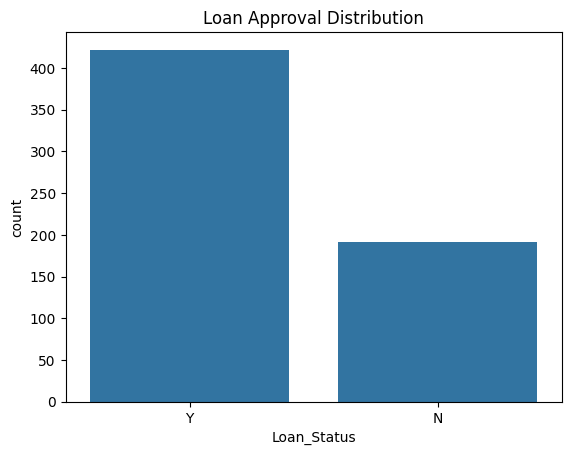

In [124]:
sns.countplot(
    x='Loan_Status',
    data=train
)

plt.title("Loan Approval Distribution")
plt.show()

# Gender vs Loan Status

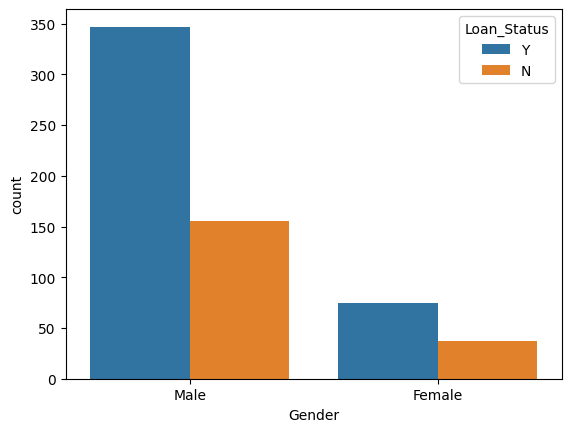

In [125]:
sns.countplot(
    x='Gender',
    hue='Loan_Status',
    data=train
)

plt.show()

# Education vs Loan Status

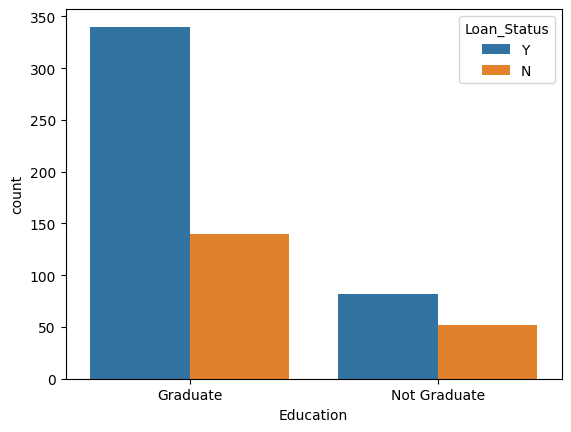

In [127]:
sns.countplot(
    x='Education',
    hue='Loan_Status',
    data=train
)

plt.show()

# Property Area vs Loan Status

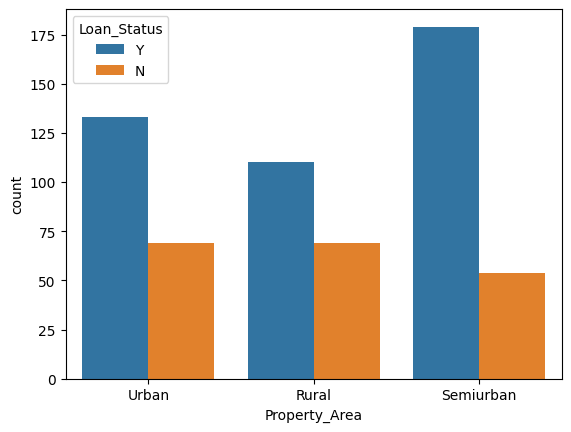

In [128]:
sns.countplot(
    x='Property_Area',
    hue='Loan_Status',
    data=train
)

plt.show()

# Credit History Analysis

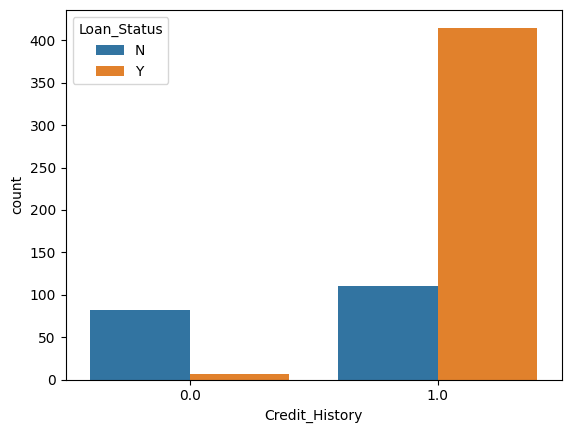

In [130]:
sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=train
)

plt.show()

# Drop Loan_ID

In [131]:
train = train.drop(
    columns=['Loan_ID'],
    errors='ignore'
)

test = test.drop(
    columns=['Loan_ID'],
    errors='ignore'
)

# Encoding
 - Label Encoding

In [134]:
le = LabelEncoder()

In [135]:
# Train Dataset

for col in train.columns:

    if train[col].dtype == 'object':

        train[col] = le.fit_transform(
            train[col]
        )

In [136]:
# Test Dataset

for col in test.columns:

    if test[col].dtype == 'object':

        test[col] = le.fit_transform(
            test[col]
        )

In [137]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# Feature Selection

In [138]:
X = train.drop(
    'Loan_Status',
    axis=1
)

y = train['Loan_Status']

In [139]:
print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [140]:
# Train Test Split

In [141]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [142]:
print(X_train.shape)
print(X_valid.shape)

(491, 11)
(123, 11)


# Model 1 - Logistic Regression

In [143]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_valid
)

print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        lr_pred
    )
)

Accuracy: 0.8617886178861789


In [144]:
# Model 2 - Decision Tree

In [145]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_valid
)

print(
    accuracy_score(
        y_valid,
        dt_pred
    )
)

0.8211382113821138


# Model 3 - Random Forest

In [146]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_valid
)

print(
    "RF Accuracy:",
    accuracy_score(
        y_valid,
        rf_pred
    )
)

RF Accuracy: 0.8455284552845529


## Evaluation
- Confusion Matrix

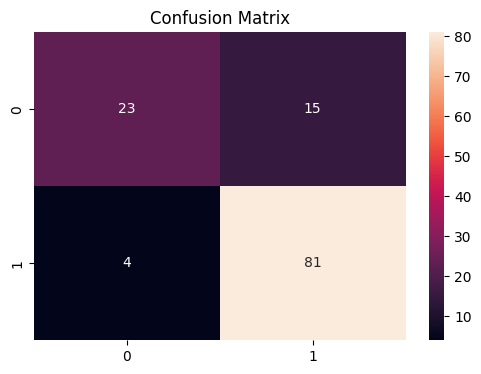

In [147]:
cm = confusion_matrix(
    y_valid,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [148]:
print(
    classification_report(
        y_valid,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.61      0.71        38
           1       0.84      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.78      0.80       123
weighted avg       0.85      0.85      0.84       123



# Feature Importance

In [149]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

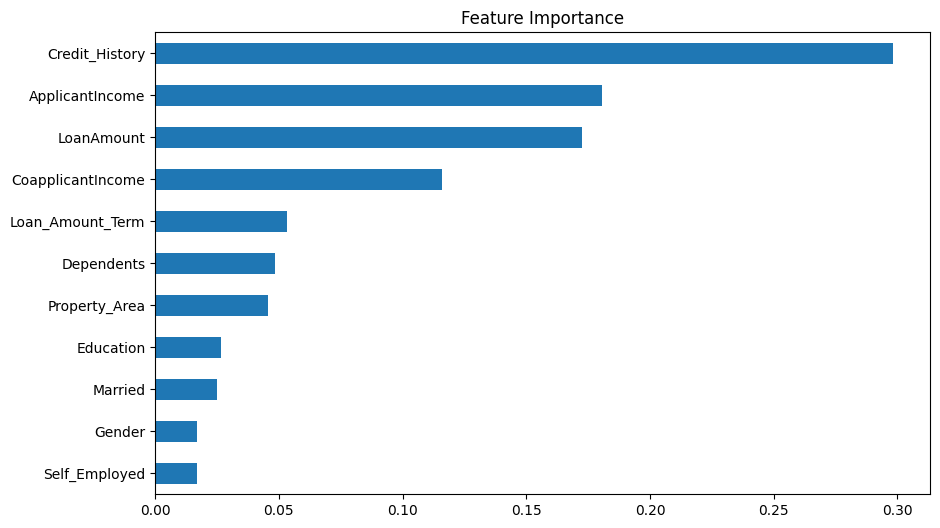

In [150]:
importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

# Predict Test Dataset

In [153]:
test_prediction = rf.predict(
    test
)

print(test_prediction[:10])

[1 1 1 1 1 1 1 0 1 1]


# Convert Prediction

In [154]:
loan_status = np.where(
    test_prediction == 1,
    'Y',
    'N'
)

# Create Submission File

In [155]:
submission = pd.DataFrame({

    'Loan_ID': test_loan_id,

    'Loan_Status': loan_status

})

In [156]:
submission.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


# Save CSV

In [157]:
submission.to_csv(
    "loan_prediction_submission.csv",
    index=False
)

print(
    "Submission File Saved"
)

Submission File Saved


# Streamlit Deployment (Internship Bonus)

In [158]:
import streamlit as st
import joblib

In [159]:
import joblib

joblib.dump(
    rf,
    "loan_model.pkl"
)

['loan_model.pkl']

## Business Insights
- Credit History is the most influential feature.
- Applicants with good credit scores are more likely to get approval.
- Semiurban areas show higher approval rates.
- Higher income improves loan approval probability.
- Random Forest outperformed Logistic Regression and Decision Tree.

# Project Objectives
- Clean and preprocess loan application data.
- Handle missing values and categorical features.
- Perform exploratory data analysis to identify important trends.
- Train multiple machine learning models.
- Compare model performance and select the best model.
- Predict loan approval status for new applicants.
- Generate business insights from the data.